# Home Assignment: Dimensionality Reduction in Chemistry (PCA, t-SNE, UMAP)



## Setup
Run this cell first. It installs RDKit and UMAP

In [12]:
!pip install -q rdkit umap-learn

---
# Part A

In [13]:
import numpy as np

## A1. PCA on two descriptors

Four molecules are described by two descriptors measured on the same scale, $(x_1, x_2)$:

$P = (7, 3), \quad Q = (1, 1), \quad R = (5, 3), \quad S = (3, 1)$

**(a)** Center the data and compute the covariance matrix using $1/N$ normalization.

**(b)** Find both eigenvalues and the corresponding unit eigenvectors. Verify that the eigenvalues sum to the trace of the covariance matrix.

**(c)** What fraction of the total variance is explained by PC1? What angle does PC1 make with the $x_1$ axis?

**(d)** Compute the PC1 scores of all four molecules. Show that the mean squared reconstruction error, when only PC1 is kept, equals the discarded eigenvalue.

**Your answer:**



In [14]:
import numpy as np

# Given data
X = np.array([[7, 3],
              [1, 1],
              [5, 3],
              [3, 1]], dtype=float)

# (a) Center data
mean = X.mean(axis=0)
X_centered = X - mean

print("Mean:", mean)
print("Centered Data:\n", X_centered)

# Covariance matrix (1/N)
N = X.shape[0]
cov = (X_centered.T @ X_centered) / N
print("\nCovariance Matrix:\n", cov)

# (b) Eigenvalues & eigenvectors
eigvals, eigvecs = np.linalg.eig(cov)

# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("\nEigenvalues:", eigvals)
print("Eigenvectors:\n", eigvecs)

# Verify trace
print("\nTrace:", np.trace(cov))
print("Sum of eigenvalues:", eigvals.sum())

# (c) Variance explained
var_explained = eigvals / eigvals.sum()
print("\nVariance explained:", var_explained)

# Angle with x1-axis (PC1)
pc1 = eigvecs[:, 0]
angle = np.degrees(np.arctan2(pc1[1], pc1[0]))
print("Angle of PC1 (degrees):", angle)

# (d) PC1 scores
scores = X_centered @ pc1
print("\nPC1 scores:", scores)

# Reconstruction using only PC1
X_reconstructed = np.outer(scores, pc1)

# Reconstruction error (MSE)
mse = np.mean(np.sum((X_centered - X_reconstructed)**2, axis=1))
print("\nReconstruction MSE:", mse)

# Compare with discarded eigenvalue
print("Discarded eigenvalue (lambda2):", eigvals[1])

Mean: [4. 2.]
Centered Data:
 [[ 3.  1.]
 [-3. -1.]
 [ 1.  1.]
 [-1. -1.]]

Covariance Matrix:
 [[5. 2.]
 [2. 1.]]

Eigenvalues: [5.82842712 0.17157288]
Eigenvectors:
 [[ 0.92387953 -0.38268343]
 [ 0.38268343  0.92387953]]

Trace: 6.0
Sum of eigenvalues: 6.0

Variance explained: [0.97140452 0.02859548]
Angle of PC1 (degrees): 22.500000000000004

PC1 scores: [ 3.15432203 -3.15432203  1.30656296 -1.30656296]

Reconstruction MSE: 0.17157287525380988
Discarded eigenvalue (lambda2): 0.17157287525380982


## A2. t-SNE conditional probabilities

A molecule $i$ has three neighbors at distances 1, 1, and 2 in descriptor space. Use

$$p_{j|i} = \frac{\exp(-d_{ij}^2 / 2\sigma_i^2)}{\sum_k \exp(-d_{ik}^2 / 2\sigma_i^2)}$$

**(a)** Compute all three $p_{j|i}$ for $\sigma_i = 1$.

**(b)** Compute the entropy $H = -\sum_j p_{j|i} \log_2 p_{j|i}$ (in bits) and the perplexity $\text{Perp} = 2^H$.

**(c)** For a dataset of $N = 10$ molecules, t-SNE symmetrizes the probabilities as $p_{ij} = (p_{j|i} + p_{i|j}) / 2N$. If $p_{j|i} = 0.45$ and $p_{i|j} = 0.25$, compute $p_{ij}$. Why is symmetrization needed?

**Your answer:**



In [15]:
# Given distances
d = np.array([1.0, 1.0, 2.0])

# (a) Compute conditional probabilities for sigma = 1
sigma = 1.0

num = np.exp(-(d**2) / (2 * sigma**2))
p = num / num.sum()

print("(a) Conditional probabilities p(j|i):")
print(p)

# (b) Entropy (base 2) and perplexity
entropy = -np.sum(p * np.log2(p))
perplexity = 2 ** entropy

print("\n(b) Entropy (bits):", entropy)
print("Perplexity:", perplexity)

# (c) Symmetrized probability
N = 10
p_ji = 0.45
p_ij_rev = 0.25

p_ij = (p_ji + p_ij_rev) / (2 * N)

print("\n(c) Symmetrized probability p_ij:", p_ij)

(a) Conditional probabilities p(j|i):
[0.44981622 0.44981622 0.10036756]

(b) Entropy (bits): 1.369792099709465
Perplexity: 2.5843332178089606

(c) Symmetrized probability p_ij: 0.034999999999999996


## A3. Heavy tails

**(a)** At what map distance $d$ does the Student-t kernel $(1 + d^2)^{-1}$ fall to 10% of its value at $d = 0$?

**(b)** Answer the same question for the Gaussian kernel $\exp(-d^2)$.

**(c)** In one or two sentences, relate your answers to the crowding problem.

**Your answer:**



In [19]:

# (a) Student-t kernel: 1 / (1 + d^2) = 0.1
d_student = np.sqrt(9)

# (b) Gaussian kernel: exp(-d^2) = 0.1
d_gaussian = np.sqrt(-np.log(0.1))

print("(a) Student-t: d =", d_student)
print("(b) Gaussian:  d =", d_gaussian)

# (c) Interpretation
print("\n(c) The Student-t kernel has heavier tails than the Gaussian kernel,")
print("so distant points retain stronger attraction. This helps t-SNE reduce")
print("the crowding problem by giving more room to moderately distant points.")

(a) Student-t: d = 3.0
(b) Gaussian:  d = 1.5174271293851462

(c) The Student-t kernel has heavier tails than the Gaussian kernel,
so distant points retain stronger attraction. This helps t-SNE reduce
the crowding problem by giving more room to moderately distant points.


## A4. UMAP fuzzy weights

For molecule $i$ with $k = 4$ nearest neighbors at distances 0.5, 1.0, 1.5, and 2.0, UMAP uses

$$w_{ij} = \exp\left(-\frac{d_{ij} - \rho_i}{\sigma_i}\right), \qquad \sum_j w_{ij} = \log_2 k$$

where $\rho_i$ is the distance to the nearest neighbor.

**(a)** Show that the normalization condition reduces to $x + x^2 + x^3 = 1$, where $x = \exp(-0.5/\sigma_i)$.

**(b)** Solve for $x$ numerically (for example by bisection) and find $\sigma_i$.

**(c)** If the weight from $i$ to its second neighbor is $w_{ij}$ and the reverse weight is $w_{ji} = 0.5$, compute the symmetrized weight using the fuzzy union $w = a + b - ab$.

**Your answer:**



In [20]:
# Scratch: check A4 here (e.g. write a small bisection loop)
import numpy as np
import math

# A4: UMAP fuzzy weights

# (a) x + x^2 + x^3 = 1
# where x = exp(-0.5 / sigma)

# (b) Solve numerically using bisection

def f(x):
    return x + x**2 + x**3 - 1

low, high = 0.0, 1.0

for _ in range(100):
    mid = (low + high) / 2

    if f(mid) > 0:
        high = mid
    else:
        low = mid

x = (low + high) / 2

# x = exp(-0.5/sigma)
sigma = -0.5 / np.log(x)

print("(a) Equation: x + x^2 + x^3 = 1")
print("(b) x =", x)
print("    sigma =", sigma)

# Calculate weights for the four neighbors
distances = [0.5, 1.0, 1.5, 2.0]
rho = 0.5

weights = [
    np.exp(-(d - rho) / sigma)
    for d in distances
]

print("\nWeights:", weights)
print("Sum of weights:", sum(weights))

# (c) Fuzzy union
# second-neighbor weight is weights[1]
a = weights[1]
b = 0.5

w = a + b - a*b

print("\n(c) Second-neighbor weight w_ij =", a)
print("Reverse weight w_ji =", b)
print("Symmetrized weight =", w)

(a) Equation: x + x^2 + x^3 = 1
(b) x = 0.5436890126920764
    sigma = 0.8205089649642442

Weights: [np.float64(1.0), np.float64(0.5436890126920764), np.float64(0.2955977425220848), np.float64(0.16071324478583887)]
Sum of weights: 2.0

(c) Second-neighbor weight w_ij = 0.5436890126920764
Reverse weight w_ji = 0.5
Symmetrized weight = 0.7718445063460382


---
# Part B: Computational practice

The code below builds a dataset of about 90 small molecules in six chemical classes, computes 11 RDKit descriptors, and applies PCA, t-SNE, and UMAP. Run every cell in order, then answer the questions in the answer cells that follow them.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness

try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
except ImportError:
    raise ImportError("RDKit is missing. Install it with:  pip install rdkit")

try:
    import umap
    HAVE_UMAP = True
except ImportError:
    HAVE_UMAP = False
    print("umap-learn not found; UMAP cells will be skipped. Install with: pip install umap-learn")

SEED = 42

## 1. Build a small molecule dataset
Six chemical classes, generated systematically so every SMILES is valid.

In [22]:
def build_dataset():
    rows = []

    def add(smiles, cls):
        rows.append({"smiles": smiles, "class": cls})

    for n in range(1, 11):
        add("C" * n + "O", "Alcohol")
    for m in range(1, 6):
        add("CC(O)" + "C" * m, "Alcohol")

    for n in range(1, 11):
        add("C" * n + "N", "Amine")
    for m in range(1, 6):
        add("CN(C)" + "C" * m, "Amine")

    for n in range(0, 10):
        add("C" * n + "C(=O)O", "Carboxylic acid")
    for m in range(1, 6):
        add("OC(=O)" + "C" * m + "C(=O)O", "Carboxylic acid")

    for n in range(1, 11):
        add("CC(=O)" + "C" * n, "Ketone")

    for n in range(1, 9):
        add("C" * n + "Cl", "Haloalkane")
    for n in range(1, 8):
        add("C" * n + "Br", "Haloalkane")

    for n in range(0, 10):
        add("c1ccccc1" + "C" * n, "Aromatic")
    for s in ["Cc1ccc(C)cc1", "Cc1cccc(C)c1", "c1ccc2ccccc2c1",
              "c1ccc(cc1)-c1ccccc1", "c1ccc2cc3ccccc3cc2c1"]:
        add(s, "Aromatic")

    return pd.DataFrame(rows)


def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "MolMR": Crippen.MolMR(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "RotBonds": Descriptors.NumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "AromRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FracCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
    }


df = build_dataset()
desc = pd.DataFrame([compute_descriptors(s) for s in df["smiles"]])
data = pd.concat([df, desc], axis=1)
feature_cols = list(desc.columns)
X_raw = data[feature_cols].to_numpy(dtype=float)

print(f"{len(data)} molecules, {len(feature_cols)} descriptors")
print(data["class"].value_counts())
data.head()

85 molecules, 11 descriptors
class
Alcohol            15
Amine              15
Carboxylic acid    15
Haloalkane         15
Aromatic           15
Ketone             10
Name: count, dtype: int64


,smiles,class,MolWt,LogP,MolMR,TPSA,HBD,HBA,RotBonds,Rings,AromRings,FracCSP3,HeavyAtoms
0,CO,Alcohol,32.042,-0.3915,8.1428,20.23,1,1,0,0,0,1.0,2
1,CCO,Alcohol,46.069,-0.0014,12.7598,20.23,1,1,0,0,0,1.0,3
2,CCCO,Alcohol,60.096,0.3887,17.3768,20.23,1,1,1,0,0,1.0,4
3,CCCCO,Alcohol,74.123,0.7788,21.9938,20.23,1,1,2,0,0,1.0,5
4,CCCCCO,Alcohol,88.150,1.1689,26.6108,20.23,1,1,3,0,0,1.0,6


## 2. Plotting helper

In [23]:
CLASSES = sorted(data["class"].unique())
MARKERS = ["o", "^", "s", "D", "v", "P"]
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#6250d6"]


def plot_by_class(ax, Y, title, xlabel="Dim 1", ylabel="Dim 2"):
    for cls, mk, col in zip(CLASSES, MARKERS, COLORS):
        idx = (data["class"] == cls).to_numpy()
        ax.scatter(Y[idx, 0], Y[idx, 1], marker=mk, c=col, s=35,
                   edgecolor="white", linewidth=0.5, label=cls)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def plot_by_value(ax, Y, values, title, label):
    sc = ax.scatter(Y[:, 0], Y[:, 1], c=values, cmap="viridis", s=35,
                    edgecolor="white", linewidth=0.5)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_title(title, fontsize=10)

## 3. PCA: raw vs standardized descriptors

Explained variance ratio (raw):          [0.8178 0.1704 0.0106 0.0011]
Explained variance ratio (standardized): [0.4828 0.2881 0.174  0.0224]


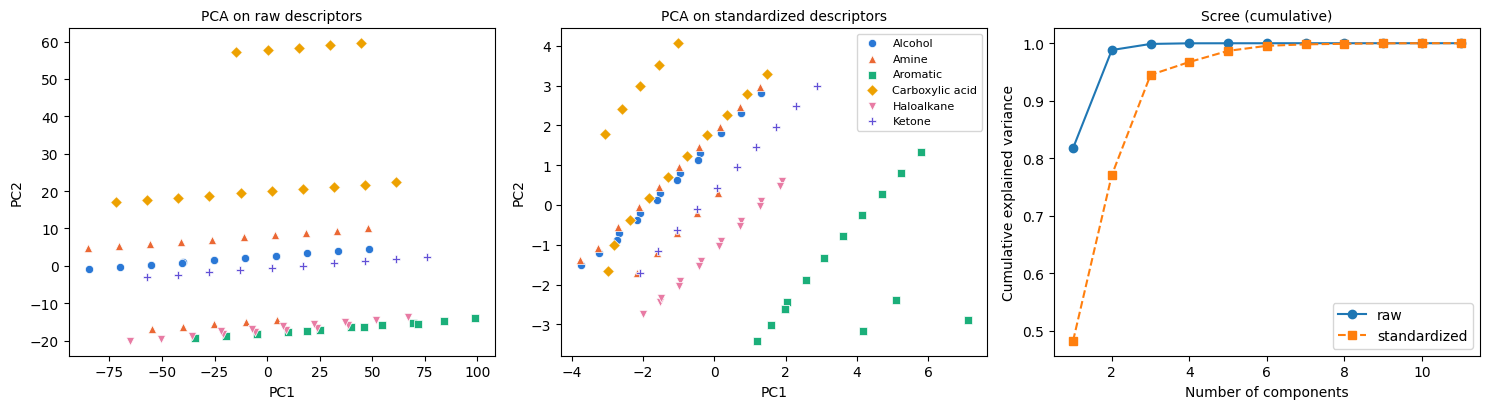

In [24]:
X_std = StandardScaler().fit_transform(X_raw)

pca_raw = PCA().fit(X_raw - X_raw.mean(axis=0))
pca_std = PCA().fit(X_std)

print("Explained variance ratio (raw):         ", np.round(pca_raw.explained_variance_ratio_[:4], 4))
print("Explained variance ratio (standardized):", np.round(pca_std.explained_variance_ratio_[:4], 4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
Y_raw = pca_raw.transform(X_raw - X_raw.mean(axis=0))[:, :2]
Y_pca = pca_std.transform(X_std)[:, :2]
plot_by_class(axes[0], Y_raw, "PCA on raw descriptors", "PC1", "PC2")
plot_by_class(axes[1], Y_pca, "PCA on standardized descriptors", "PC1", "PC2")

k = np.arange(1, len(feature_cols) + 1)
axes[2].plot(k, np.cumsum(pca_raw.explained_variance_ratio_), "o-", label="raw")
axes[2].plot(k, np.cumsum(pca_std.explained_variance_ratio_), "s--", label="standardized")
axes[2].set_xlabel("Number of components")
axes[2].set_ylabel("Cumulative explained variance")
axes[2].set_title("Scree (cumulative)", fontsize=10)
axes[2].legend()
axes[1].legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig("fig1_pca.png", dpi=150)
plt.show()

### PCA loadings (standardized)

In [25]:
loadings = pd.DataFrame(pca_std.components_[:2].T, index=feature_cols, columns=["PC1", "PC2"])
print(loadings.round(3).sort_values("PC1", key=abs, ascending=False))

              PC1    PC2
LogP        0.404  0.116
MolMR       0.389  0.239
HeavyAtoms  0.355  0.297
MolWt       0.348  0.295
Rings       0.319 -0.246
AromRings   0.319 -0.246
HBA        -0.252  0.360
HBD        -0.231  0.320
TPSA       -0.211  0.360
FracCSP3   -0.195  0.205
RotBonds    0.187  0.480


### YOUR TURN (B1)
1. Why does raw-data PCA give a very high PC1 explained variance? Which descriptor dominates?
2. Using the loadings, give a chemical name to PC1 and PC2 of the standardized PCA.
3. How many components are needed to reach 90% of the variance (standardized)?

**Your answer:**



In [26]:
# B1: PCA interpretation

# 1. Raw PCA: dominant descriptor
raw_variances = pca_raw.explained_variance_ratio_

print("Raw PCA PC1 explained variance:",
      round(raw_variances[0], 4))

print("\nDescriptor standard deviations:")
print(pd.Series(X_raw.std(axis=0), index=feature_cols)
      .sort_values(ascending=False))

# 2. Standardized PCA loadings
loadings = pd.DataFrame(
    pca_std.components_[:2].T,
    index=feature_cols,
    columns=["PC1", "PC2"]
)

print("\nPC1 loadings:")
print(loadings["PC1"].sort_values(key=abs, ascending=False))

print("\nPC2 loadings:")
print(loadings["PC2"].sort_values(key=abs, ascending=False))

# 3. Number of components for 90% variance
cum_var = np.cumsum(pca_std.explained_variance_ratio_)
n90 = np.searchsorted(cum_var, 0.90) + 1

print("\nComponents needed for 90% variance:", n90)
print("Cumulative variance:", round(cum_var[n90 - 1], 4))

Raw PCA PC1 explained variance: 0.8178

Descriptor standard deviations:
MolWt         40.051794
TPSA          19.178809
MolMR         13.503568
HeavyAtoms     3.088409
RotBonds       2.579504
LogP           1.255252
HBD            0.605625
HBA            0.570315
Rings          0.539640
AromRings      0.539640
FracCSP3       0.300387
dtype: float64

PC1 loadings:
LogP          0.404307
MolMR         0.389055
HeavyAtoms    0.354820
MolWt         0.347673
Rings         0.319074
AromRings     0.319074
HBA          -0.252190
HBD          -0.231453
TPSA         -0.210806
FracCSP3     -0.195105
RotBonds      0.187369
Name: PC1, dtype: float64

PC2 loadings:
RotBonds      0.479839
HBA           0.359858
TPSA          0.359854
HBD           0.319730
HeavyAtoms    0.296577
MolWt         0.294961
Rings        -0.245878
AromRings    -0.245878
MolMR         0.239077
FracCSP3      0.205136
LogP          0.115858
Name: PC2, dtype: float64

Components needed for 90% variance: 3
Cumulative variance: 0

## 4. t-SNE: effect of perplexity and random seed

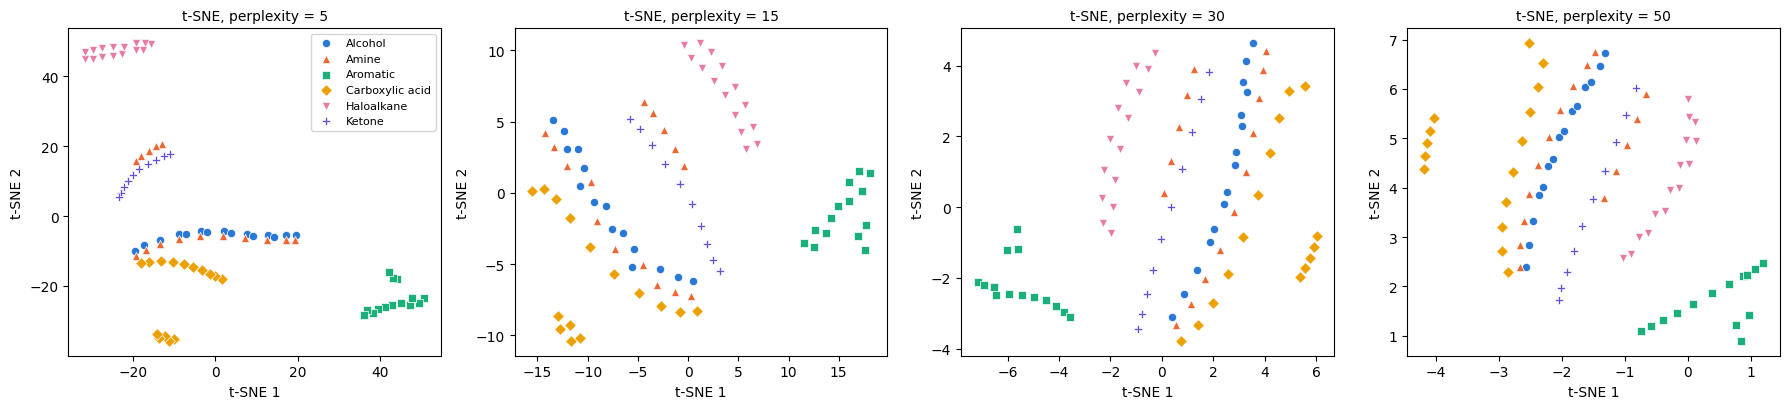

In [27]:
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, len(perplexities), figsize=(18, 4.2))
tsne_results = {}
for ax, p in zip(axes, perplexities):
    Y = TSNE(n_components=2, perplexity=p, init="pca", learning_rate="auto",
             random_state=SEED).fit_transform(X_std)
    tsne_results[p] = Y
    plot_by_class(ax, Y, f"t-SNE, perplexity = {p}", "t-SNE 1", "t-SNE 2")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig2_tsne_perplexity.png", dpi=150)
plt.show()

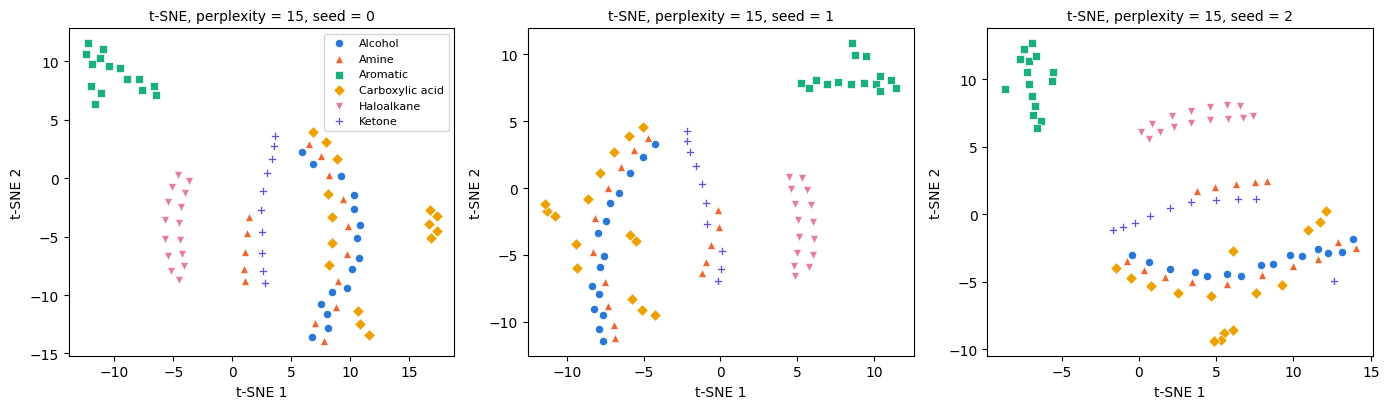

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, seed in zip(axes, [0, 1, 2]):
    Y = TSNE(n_components=2, perplexity=15, init="random", learning_rate="auto",
             random_state=seed).fit_transform(X_std)
    plot_by_class(ax, Y, f"t-SNE, perplexity = 15, seed = {seed}", "t-SNE 1", "t-SNE 2")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig3_tsne_seeds.png", dpi=150)
plt.show()

### YOUR TURN (B2)
1. How does the map change as perplexity increases from 5 to 50?
2. Which features stay the same across seeds, and which change?
3. Why is perplexity = 100 not allowed for this dataset?

**Your answer:**



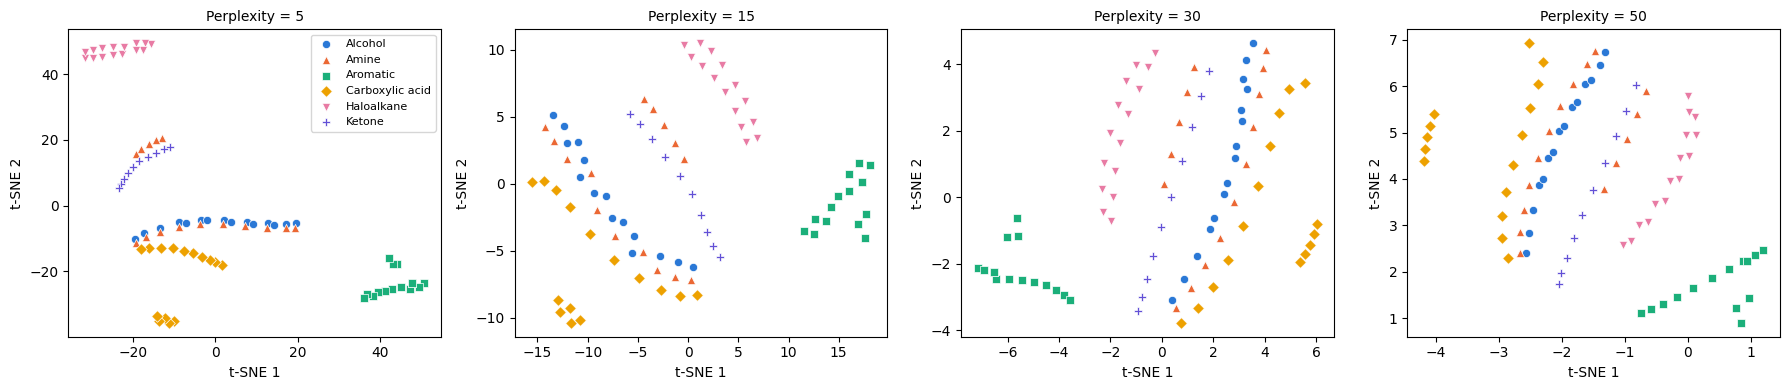

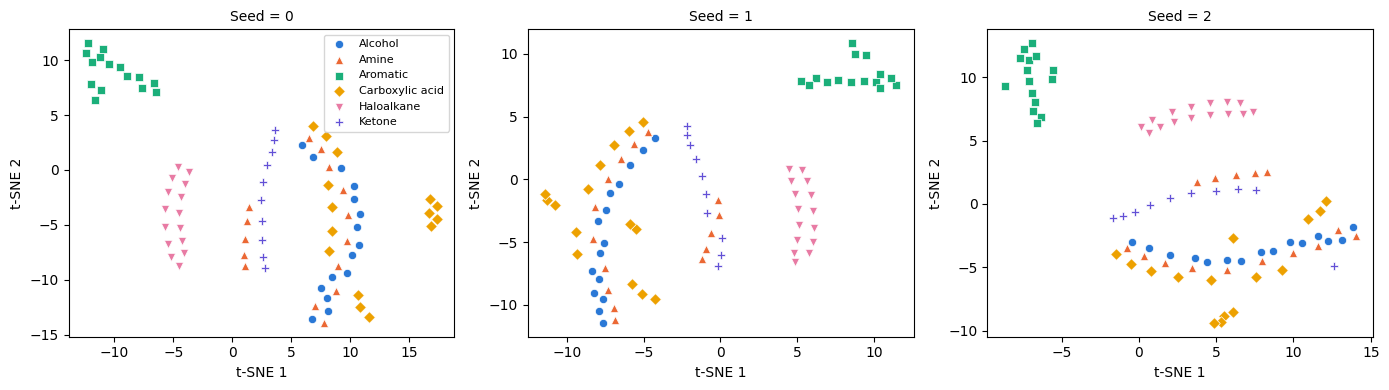

Perplexity = 100 is not allowed because
perplexity must be smaller than the number of samples.
Number of samples = 85


In [29]:
# B2: t-SNE effect of perplexity and random seed

# Effect of perplexity
perplexities = [5, 15, 30, 50]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

tsne_results = {}

for ax, p in zip(axes, perplexities):
    Y = TSNE(
        n_components=2,
        perplexity=p,
        init="pca",
        learning_rate="auto",
        random_state=SEED
    ).fit_transform(X_std)

    tsne_results[p] = Y
    plot_by_class(
        ax, Y,
        f"Perplexity = {p}",
        "t-SNE 1",
        "t-SNE 2"
    )

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# Effect of random seed
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, seed in zip(axes, [0, 1, 2]):
    Y = TSNE(
        n_components=2,
        perplexity=15,
        init="random",
        learning_rate="auto",
        random_state=seed
    ).fit_transform(X_std)

    plot_by_class(
        ax, Y,
        f"Seed = {seed}",
        "t-SNE 1",
        "t-SNE 2"
    )

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


print("Perplexity = 100 is not allowed because")
print("perplexity must be smaller than the number of samples.")
print("Number of samples =", len(X_std))

## 5. UMAP: effect of n_neighbors and min_dist

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


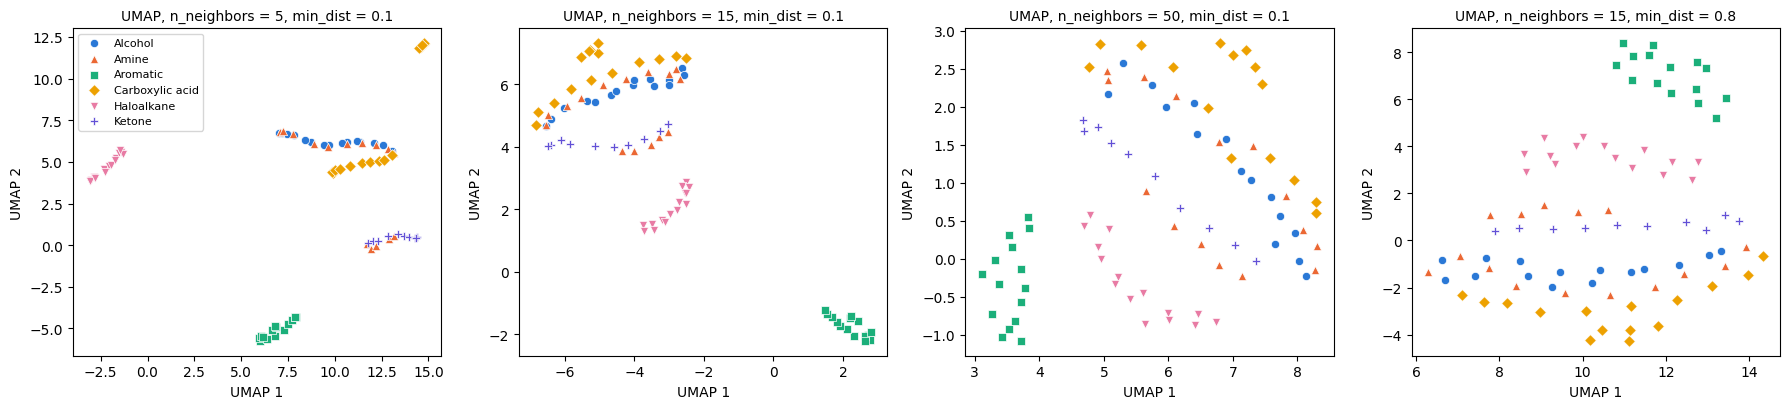

In [30]:
umap_results = {}
if HAVE_UMAP:
    settings = [(5, 0.1), (15, 0.1), (50, 0.1), (15, 0.8)]
    fig, axes = plt.subplots(1, len(settings), figsize=(18, 4.2))
    for ax, (nn, md) in zip(axes, settings):
        Y = umap.UMAP(n_neighbors=nn, min_dist=md, random_state=SEED).fit_transform(X_std)
        umap_results[(nn, md)] = Y
        plot_by_class(ax, Y, f"UMAP, n_neighbors = {nn}, min_dist = {md}", "UMAP 1", "UMAP 2")
    axes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("fig4_umap.png", dpi=150)
    plt.show()

### YOUR TURN (B3)
1. Compare n_neighbors = 5 and 50. Which shows more local detail, which more global layout?
2. What does increasing min_dist from 0.1 to 0.8 do to the clusters?

**Your answer:**



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


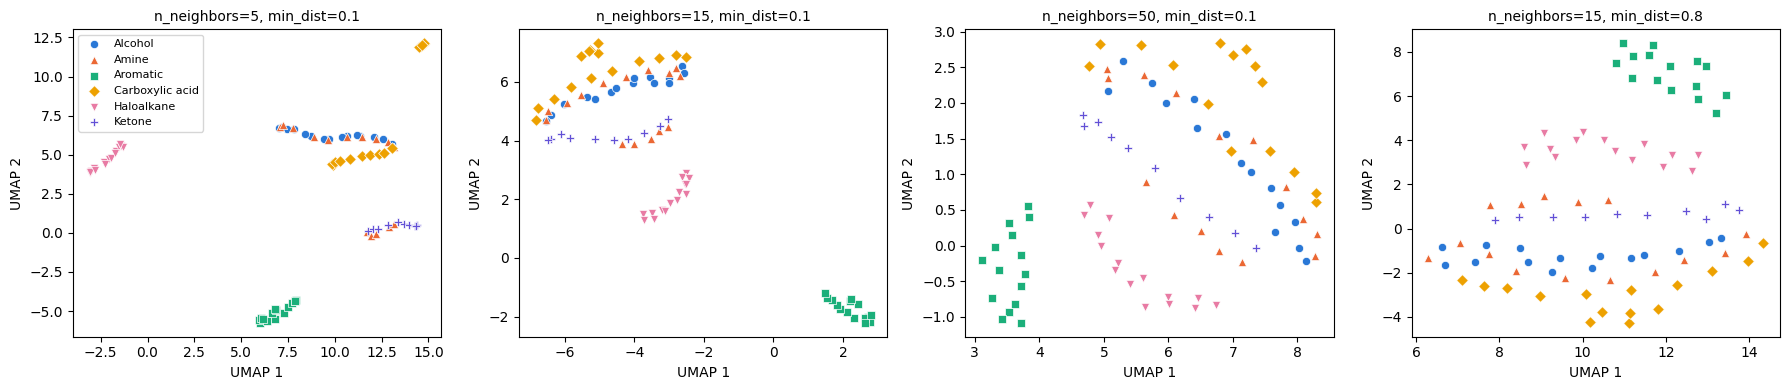

In [31]:
# B3: UMAP effect of n_neighbors and min_dist

settings = [
    (5, 0.1),
    (15, 0.1),
    (50, 0.1),
    (15, 0.8)
]

umap_results = {}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (nn, md) in zip(axes, settings):

    Y = umap.UMAP(
        n_neighbors=nn,
        min_dist=md,
        random_state=SEED
    ).fit_transform(X_std)

    umap_results[(nn, md)] = Y

    plot_by_class(
        ax, Y,
        f"n_neighbors={nn}, min_dist={md}",
        "UMAP 1",
        "UMAP 2"
    )

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Colour by a continuous property

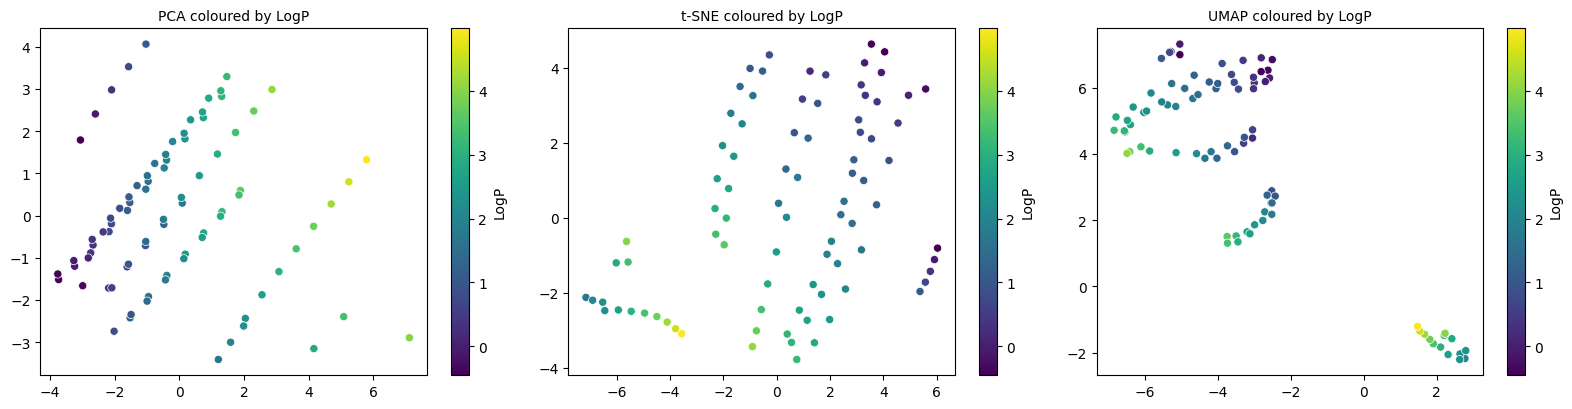

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
plot_by_value(axes[0], Y_pca, data["LogP"], "PCA coloured by LogP", "LogP")
plot_by_value(axes[1], tsne_results[30], data["LogP"], "t-SNE coloured by LogP", "LogP")
if HAVE_UMAP:
    plot_by_value(axes[2], umap_results[(15, 0.1)], data["LogP"], "UMAP coloured by LogP", "LogP")
else:
    axes[2].axis("off")
plt.tight_layout()
plt.savefig("fig5_logp.png", dpi=150)
plt.show()

### YOUR TURN (B4)
Inside each class cluster, is there a smooth LogP gradient? What structural change
(hint: chain length) produces it?

**Your answer:**



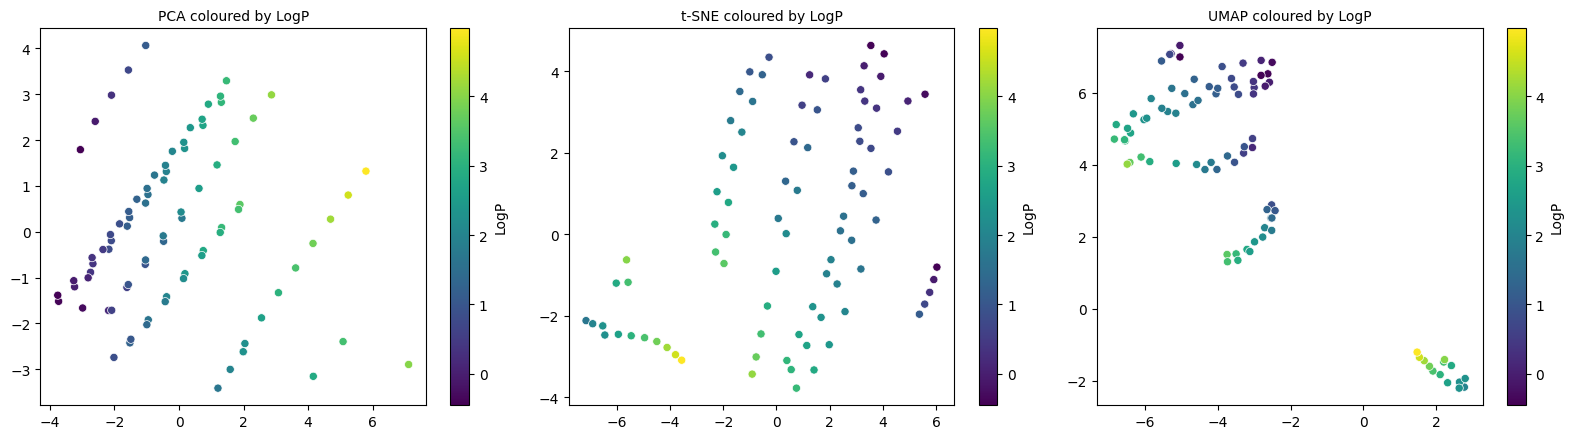

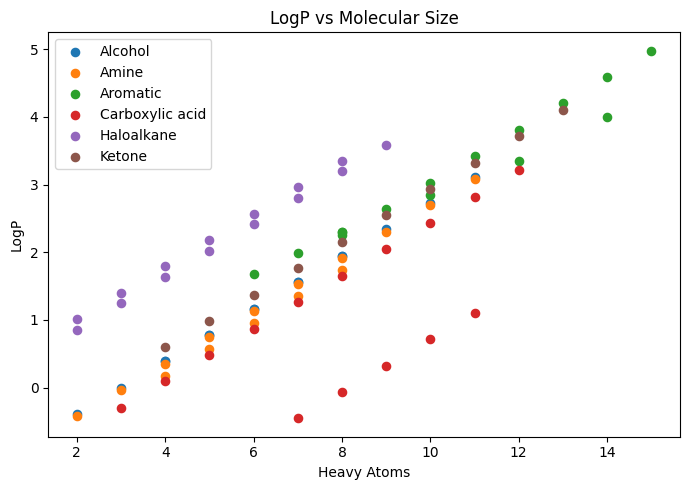

In [33]:
# B4: LogP gradient inside chemical classes

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# PCA
plot_by_value(
    axes[0],
    Y_pca,
    data["LogP"],
    "PCA coloured by LogP",
    "LogP"
)

# t-SNE
plot_by_value(
    axes[1],
    tsne_results[30],
    data["LogP"],
    "t-SNE coloured by LogP",
    "LogP"
)

# UMAP
plot_by_value(
    axes[2],
    umap_results[(15, 0.1)],
    data["LogP"],
    "UMAP coloured by LogP",
    "LogP"
)

plt.tight_layout()
plt.show()


# Show LogP against molecular size / carbon-chain size
plt.figure(figsize=(7, 5))
for cls in sorted(data["class"].unique()):
    subset = data[data["class"] == cls]
    plt.scatter(
        subset["HeavyAtoms"],
        subset["LogP"],
        label=cls,
        s=35
    )

plt.xlabel("Heavy Atoms")
plt.ylabel("LogP")
plt.title("LogP vs Molecular Size")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Quantitative comparison: trustworthiness
Trustworthiness (0 to 1) measures how well each point's nearest neighbours in the map
were also neighbours in the original space. 1 means perfect local preservation.

In [34]:
emb = {"PCA (2 PCs)": Y_pca, "t-SNE (perp 30)": tsne_results[30]}
if HAVE_UMAP:
    emb["UMAP (nn 15)"] = umap_results[(15, 0.1)]

for k_nn in [5, 15]:
    for name, Y in emb.items():
        t = trustworthiness(X_std, Y, n_neighbors=k_nn)
        print(f"k = {k_nn:2d}  {name:18s} trustworthiness = {t:.3f}")

k =  5  PCA (2 PCs)        trustworthiness = 0.986
k =  5  t-SNE (perp 30)    trustworthiness = 0.996
k =  5  UMAP (nn 15)       trustworthiness = 0.991
k = 15  PCA (2 PCs)        trustworthiness = 0.981
k = 15  t-SNE (perp 30)    trustworthiness = 0.971
k = 15  UMAP (nn 15)       trustworthiness = 0.936


### YOUR TURN (B5)
1. Which method preserves local neighbourhoods best? Is that what you expected?
2. Trustworthiness says nothing about distances between clusters. Propose a check
   for global structure (hint: correlate pairwise distances in the original and 2D spaces).

**Your answer:**


In [35]:
# B5: Quantitative comparison of local and global structure

from sklearn.manifold import trustworthiness
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr


# ---------- Local structure ----------
embeddings = {
    "PCA (2 PCs)": Y_pca,
    "t-SNE (perp 30)": tsne_results[30],
    "UMAP (nn 15)": umap_results[(15, 0.1)]
}

print("TRUSTWORTHINESS")
print("-" * 50)

for k_nn in [5, 15]:
    print(f"\nk = {k_nn}")

    for name, Y in embeddings.items():
        score = trustworthiness(
            X_std,
            Y,
            n_neighbors=k_nn
        )

        print(f"{name:20s}: {score:.3f}")


# ---------- Global structure ----------
# Compare pairwise distances in original 11-D space
# with pairwise distances in each 2-D embedding.

original_dist = pdist(X_std, metric="euclidean")

print("\n\nGLOBAL STRUCTURE")
print("-" * 50)

for name, Y in embeddings.items():

    embedded_dist = pdist(Y, metric="euclidean")

    correlation, p_value = spearmanr(
        original_dist,
        embedded_dist
    )

    print(
        f"{name:20s}: "
        f"Spearman correlation = {correlation:.3f}, "
        f"p-value = {p_value:.3e}"
    )

TRUSTWORTHINESS
--------------------------------------------------

k = 5
PCA (2 PCs)         : 0.986
t-SNE (perp 30)     : 0.996
UMAP (nn 15)        : 0.991

k = 15
PCA (2 PCs)         : 0.981
t-SNE (perp 30)     : 0.971
UMAP (nn 15)        : 0.936


GLOBAL STRUCTURE
--------------------------------------------------
PCA (2 PCs)         : Spearman correlation = 0.954, p-value = 0.000e+00
t-SNE (perp 30)     : Spearman correlation = 0.866, p-value = 0.000e+00
UMAP (nn 15)        : Spearman correlation = 0.756, p-value = 0.000e+00


In [ ]:
# Your code for the global-structure check
# Hint: from scipy.spatial.distance import pdist; from scipy.stats import spearmanr